In [110]:
!pip install rdkit
import numpy as np
import pandas as pd
from rdkit import Chem
import matplotlib.pyplot as plt
import seaborn as sns
from rdkit.Chem import AllChem
from rdkit import DataStructs
from rdkit.Chem import Draw


In [111]:
url = "https://deepchemdata.s3-us-west-1.amazonaws.com/datasets/clintox.csv.gz"
df = pd.read_csv(url,compression='gzip')
df.head(3)


,smiles,FDA_APPROVED,CT_TOX
0,*C(=O)[C@H](CCCCNC(=O)OCCOC)NC(=O)OCCOC,1,0
1,[C@@H]1([C@@H]([C@@H]([C@H]([C@@H]([C@@H]1Cl)C...,1,0
2,[C@H]([C@@H]([C@@H](C(=O)[O-])O)O)([C@H](C(=O)...,1,0


In [112]:
df.shape

(1484, 3)

In [113]:
df.isnull().sum()


,0
smiles,0
FDA_APPROVED,0
CT_TOX,0


In [114]:
df['FDA_APPROVED'].value_counts()


,count
FDA_APPROVED,
1,1390
0,94


In [115]:
df['CT_TOX'].value_counts()

,count
CT_TOX,
0,1372
1,112


In [116]:
y = df[['FDA_APPROVED','CT_TOX']].values

In [117]:
def smiles_to_fp(smiles):
    try:
        mol = Chem.MolFromSmiles(smiles)
        if mol is None:
          return np.zeros((2048,), dtype=int)

        fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius=2, nBits=2048)
        fp_arr = np.zeros((2048,), dtype=int)
        DataStructs.ConvertToNumpyArray(fp, fp_arr)
        return fp_arr
    except:
          return np.zeros((2048,), dtype=int)

In [118]:
df.head(3)

,smiles,FDA_APPROVED,CT_TOX
0,*C(=O)[C@H](CCCCNC(=O)OCCOC)NC(=O)OCCOC,1,0
1,[C@@H]1([C@@H]([C@@H]([C@H]([C@@H]([C@@H]1Cl)C...,1,0
2,[C@H]([C@@H]([C@@H](C(=O)[O-])O)O)([C@H](C(=O)...,1,0


In [119]:
mol_list = []
for item in df['smiles']:
  mol_list.append(item)
df['mol'] = mol_list
x_tain = np.array(df["mol"].apply(smiles_to_fp).tolist())
y_train= df[['FDA_APPROVED', 'CT_TOX']].values

print("Features Matrix (x) Shape:", x.shape)
print("Targets (y) Shape:", y.shape)

[04:12:48] DEPRECATION WARNING: please use MorganGenerator
[04:12:48] DEPRECATION WARNING: please use MorganGenerator
[04:12:48] DEPRECATION WARNING: please use MorganGenerator
[04:12:48] DEPRECATION WARNING: please use MorganGenerator
[04:12:48] DEPRECATION WARNING: please use MorganGenerator
[04:12:48] DEPRECATION WARNING: please use MorganGenerator
[04:12:48] DEPRECATION WARNING: please use MorganGenerator
[04:12:48] Explicit valence for atom # 0 N, 4, is greater than permitted
[04:12:48] DEPRECATION WARNING: please use MorganGenerator
[04:12:48] DEPRECATION WARNING: please use MorganGenerator
[04:12:48] DEPRECATION WARNING: please use MorganGenerator
[04:12:48] DEPRECATION WARNING: please use MorganGenerator
[04:12:48] DEPRECATION WARNING: please use MorganGenerator
[04:12:48] DEPRECATION WARNING: please use MorganGenerator
[04:12:48] DEPRECATION WARNING: please use MorganGenerator
[04:12:48] DEPRECATION WARNING: please use MorganGenerator
[04:12:48] DEPRECATION WARNING: please use

Features Matrix (x) Shape: (1484, 2048)
Targets (y) Shape: (1484, 2)


In [120]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [121]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.multioutput import MultiOutputClassifier


In [122]:
rf = RandomForestClassifier(n_estimators = 100,random_state=42)


In [123]:
multi_target_model = MultiOutputClassifier(rf, n_jobs=-1)

In [124]:
multi_target_model.fit(x_train, y_train)

MultiOutputClassifier(estimator=RandomForestClassifier(random_state=42),
                      n_jobs=-1)

In [125]:
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, confusion_matrix

In [126]:
Y_pred = multi_target_model.predict(x_test)

In [127]:
Y_pred_proba = multi_target_model.predict_proba(x_test)

In [128]:
Y_pred_proba_fda = Y_pred_proba[0][:, 1]
Y_pred_proba_tox = Y_pred_proba[1][:, 1]

In [129]:
print("FDA")
print(f"Accuracy: {accuracy_score(y_test[:, 0], Y_pred[:, 0]):.4f}")
print(f"ROC-AUC Score: {roc_auc_score(y_test[:, 0], Y_pred_proba_fda):.4f}")
print("\nClassification Report:\n", classification_report(y_test[:, 0], Y_pred[:, 0]))

FDA
Accuracy: 0.9259
ROC-AUC Score: 0.8391

Classification Report:
               precision    recall  f1-score   support

           0       0.33      0.05      0.08        21
           1       0.93      0.99      0.96       276

    accuracy                           0.93       297
   macro avg       0.63      0.52      0.52       297
weighted avg       0.89      0.93      0.90       297



In [130]:
print("CT_TOX")
print(f"Accuracy: {accuracy_score(y_test[:, 1], Y_pred[:, 1]):.4f}")
print(f"ROC-AUC Score: {roc_auc_score(y_test[:, 1], Y_pred_proba_tox):.4f}")
print("\nClassification Report:\n", classification_report(y_test[:, 1], Y_pred[:, 1]))

CT_TOX
Accuracy: 0.9192
ROC-AUC Score: 0.7737

Classification Report:
               precision    recall  f1-score   support

           0       0.92      1.00      0.96       273
           1       0.50      0.04      0.08        24

    accuracy                           0.92       297
   macro avg       0.71      0.52      0.52       297
weighted avg       0.89      0.92      0.89       297



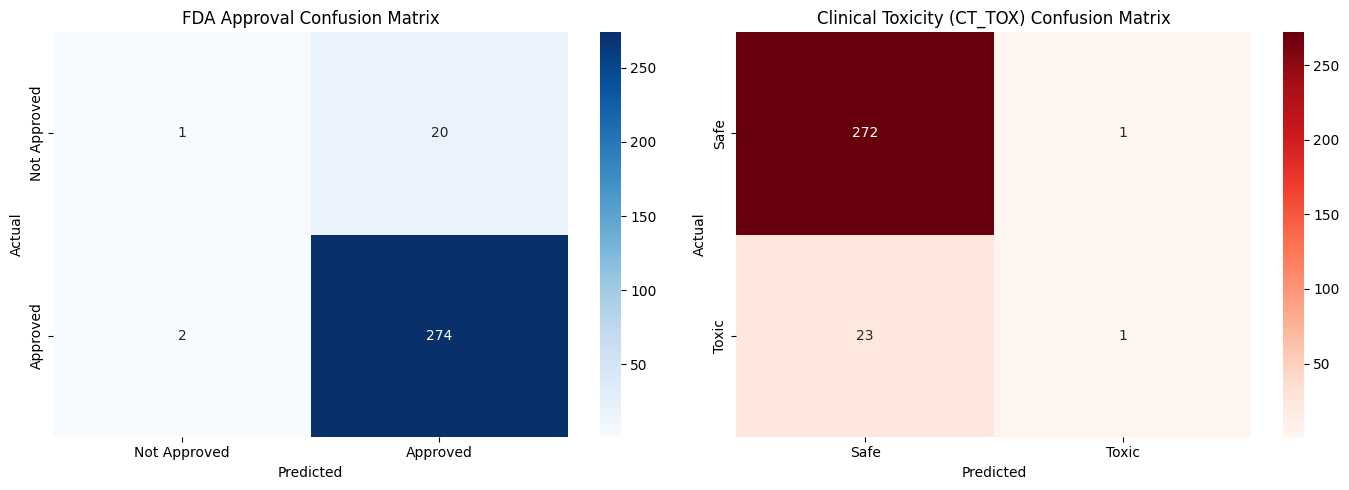

In [131]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

#FDA
cm_fda = confusion_matrix(y_test[:, 0], Y_pred[:, 0])
sns.heatmap(cm_fda, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Not Approved', 'Approved'], yticklabels=['Not Approved', 'Approved'])
axes[0].set_title('FDA Approval Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
#CM_TOX
cm_tox = confusion_matrix(y_test[:, 1], Y_pred[:, 1])
sns.heatmap(cm_tox, annot=True, fmt='d', cmap='Reds', ax=axes[1],
            xticklabels=['Safe', 'Toxic'], yticklabels=['Safe', 'Toxic'])
axes[1].set_title('Clinical Toxicity (CT_TOX) Confusion Matrix')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

In [132]:
import joblib
joblib.dump(multi_target_model, 'clintox_multi_target_model.joblib')
print("Model file successfully saved as 'clintox_multi_target_model.joblib'! 💾")

Model file successfully saved as 'clintox_multi_target_model.joblib'! 💾
